In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\NorthBridge_Health\Data\NorthBridgeDataset.xlsx"

# Load all sheets at once into a dictionary
sheets = pd.read_excel(file_path, sheet_name=None)

# Print sheet names
print("Sheets found in the Excel file:")
print(list(sheets.keys()))

# Load individual sheets
tickets = sheets["Tickets"]
clients = sheets["Clients"]
agents = sheets["Agents"]
audit = sheets["TicketAuditLog"]
escalations = sheets["EscalationLog"]

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)


Sheets found in the Excel file:
['README', 'PriorityLevels', 'TicketCategories', 'SLADefinitions', 'Agents', 'Clients', 'Tickets', 'TicketAuditLog', 'EscalationLog']


In [2]:
for sheet, df in sheets.items():
    print(f"\n===== Sheet: {sheet} =====")
    print(df.columns.tolist())


===== Sheet: README =====
['NorthBridge Health Services Ltd', 'Customer Service Ticket & SLA Optimisation System - Dataset']

===== Sheet: PriorityLevels =====
['PriorityID', 'PriorityLabel', 'Description']

===== Sheet: TicketCategories =====
['CategoryID', 'CategoryName', 'DefaultPriorityID', 'RequiresSpecialist', 'Description']

===== Sheet: SLADefinitions =====
['SLAID', 'ContractTier', 'PriorityID', 'FirstResponseHours', 'ResolutionHours', 'EscalationTriggerHours', 'EffectiveFrom']

===== Sheet: Agents =====
['AgentID', 'FullName', 'TeamID', 'Role', 'Specialisms', 'Hub', 'DailyCapacity', 'IsActive']

===== Sheet: Clients =====
['ClientID', 'ClientName', 'ClientType', 'ContractTier', 'AccountManagerID', 'Region', 'ContractStartDate', 'ContractEndDate', 'SLACreditClause', 'IsActive']

===== Sheet: Tickets =====
['TicketID', 'TicketReference', 'ClientID', 'PatientRef', 'CategoryID', 'PriorityID', 'Status', 'AssignedAgentID', 'CreatedAt', 'FirstResponseAt', 'ResolvedAt', 'SLADueAt', 

In [3]:
def preview_df(df, name="DATAFRAME"):
    print(f"\n{'='*70}")
    print(f"📌 PREVIEW: {name.upper()}")
    print(f"{'='*70}")

    # -----------------------------
    # DISSHT
    # -----------------------------
    print("\n🔹 DESCRIBE")
    try:
        print(df.describe(include='all'))
    except:
        print("Describe failed (non-numeric or mixed types).")

    print("\n🔹 INFO")
    print(df.info())

    print("\n🔹 SAMPLE (5 rows)")
    print(df.sample(5))

    print("\n🔹 SHAPE")
    print(df.shape)

    print("\n🔹 HEAD")
    print(df.head())

    print("\n🔹 TAIL")
    print(df.tail())

    # -----------------------------
    # NUDCD
    # -----------------------------
    print("\n🔹 NULL VALUES")
    print(df.isna().sum())

    print("\n🔹 UNIQUE VALUES")
    print(df.nunique())

    print("\n🔹 DUPLICATES")
    print(df.duplicated().sum())

    print("\n🔹 COLUMNS")
    print(df.columns.tolist())

    print("\n🔹 DTYPES")
    print(df.dtypes)

    print(f"\n{'='*70}\n")


In [4]:
preview_df(tickets, "Tickets")
preview_df(clients, "Clients")
preview_df(agents, "Agents")
preview_df(audit, "TicketAuditLog")
preview_df(escalations, "EscalationLog")


📌 PREVIEW: TICKETS

🔹 DESCRIBE
           TicketID TicketReference     ClientID PatientRef   CategoryID  \
count   3500.000000            3500  3500.000000       3500  3500.000000   
unique          NaN            3500          NaN       3441          NaN   
top             NaN   NB-2024-00001          NaN   PT-39332          NaN   
freq            NaN               1          NaN          3          NaN   
mean    1750.500000             NaN    40.244857        NaN     2.389429   
std     1010.507298             NaN    22.637577        NaN     1.345471   
min        1.000000             NaN     1.000000        NaN     1.000000   
25%      875.750000             NaN    22.000000        NaN     1.000000   
50%     1750.500000             NaN    40.000000        NaN     2.000000   
75%     2625.250000             NaN    59.000000        NaN     3.000000   
max     3500.000000             NaN    80.000000        NaN     5.000000   

         PriorityID  Status  AssignedAgentID         Cr

Issues Found 
TICKETS — Cleaning Required
Columns with NaN:
FirstResponseAt → 46 missing, ResolvedAt → 199 missing, ResolutionNotes → 199 missing

CLIENTS IS GENERALLY CLEAN, however the timestamps are strings: ContractStartDate and ContractEndDate

In [45]:
def clean_dates(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

def clean_text(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.lower()
    return df


In [46]:
# Apply cleaning 
# Tickets
tickets = clean_dates(tickets, ["CreatedAt", "FirstResponseAt", "ResolvedAt", "SLADueAt"])
tickets = clean_text(tickets, ["Status", "Channel"])
tickets["ResolutionNotes"] = tickets["ResolutionNotes"].fillna("no_notes")

# Clients
clients = clean_dates(clients, ["ContractStartDate", "ContractEndDate"])
clients = clean_text(clients, ["ClientName", "ClientType", "Region", "ContractTier"])

# Agents
agents = clean_text(agents, ["FullName", "Role", "Specialisms", "Hub"])
agents["DailyCapacity"] = pd.to_numeric(agents["DailyCapacity"], errors="coerce")

# Audit Log
audit = clean_dates(audit, ["ActionAt"])
audit = clean_text(audit, ["ActionType", "PreviousValue", "NewValue", "Notes"])

# Escalation Log
escalations = clean_dates(escalations, ["EscalatedAt"])
escalations["EscalationReason"] = escalations["EscalationReason"].fillna("unknown")


In [47]:
#Preview after cleaning 
preview_df(tickets, "Tickets")
preview_df(clients, "Clients")
preview_df(agents, "Agents")
preview_df(audit, "TicketAuditLog")
preview_df(escalations, "EscalationLog")



📌 PREVIEW: TICKETS

🔹 DESCRIBE
           TicketID TicketReference     ClientID PatientRef   CategoryID  \
count   3500.000000            3500  3500.000000       3500  3500.000000   
unique          NaN            3500          NaN       3441          NaN   
top             NaN   NB-2024-00001          NaN   PT-39332          NaN   
freq            NaN               1          NaN          3          NaN   
mean    1750.500000             NaN    40.244857        NaN     2.389429   
min        1.000000             NaN     1.000000        NaN     1.000000   
25%      875.750000             NaN    22.000000        NaN     1.000000   
50%     1750.500000             NaN    40.000000        NaN     2.000000   
75%     2625.250000             NaN    59.000000        NaN     3.000000   
max     3500.000000             NaN    80.000000        NaN     5.000000   
std     1010.507298             NaN    22.637577        NaN     1.345471   

         PriorityID  Status  AssignedAgentID           

In [48]:
# Loop through each sheet and show HEAD + DTYPES
for sheet_name, df in sheets.items():
    print(f"\n{'='*70}")
    print(f"📌 SHEET: {sheet_name}")
    print(f"{'='*70}")

    print("\n🔹 DTYPES")
    print(df.dtypes)

    print("\n")



📌 SHEET: README

🔹 DTYPES
NorthBridge Health Services Ltd                                   str
Customer Service Ticket & SLA Optimisation System - Dataset    object
dtype: object



📌 SHEET: PriorityLevels

🔹 DTYPES
PriorityID       int64
PriorityLabel      str
Description        str
dtype: object



📌 SHEET: TicketCategories

🔹 DTYPES
CategoryID            int64
CategoryName            str
DefaultPriorityID     int64
RequiresSpecialist    int64
Description             str
dtype: object



📌 SHEET: SLADefinitions

🔹 DTYPES
SLAID                       int64
ContractTier                  str
PriorityID                  int64
FirstResponseHours        float64
ResolutionHours             int64
EscalationTriggerHours    float64
EffectiveFrom                 str
dtype: object



📌 SHEET: Agents

🔹 DTYPES
AgentID          int64
FullName           str
TeamID           int64
Role               str
Specialisms        str
Hub                str
DailyCapacity    int64
IsActive         int64
dtyp

# EDA FUNCTIONS

def plot_category_counts(df, column):
    if column not in df.columns:
        return
    plt.figure(figsize=(10,6))
    df[column].value_counts().plot(kind="barh")
    plt.title(f"{column} Distribution", fontsize=20)
    plt.xlabel("Count", fontsize=16)
    plt.ylabel(column, fontsize=16)
    plt.tight_layout()
    plt.show()

def plot_correlation(df):
    numeric = df.select_dtypes(include=["int64", "float64"])
    if numeric.empty:
        return
    plt.figure(figsize=(16,10))
    sns.heatmap(numeric.corr(), cmap="coolwarm", annot=False)
    plt.title("Correlation Heatmap", fontsize=20)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_sla_trend(df):
    if "CreatedAt" not in df.columns or "SLABreached" not in df.columns:
        return
    df["CreatedAt"] = pd.to_datetime(df["CreatedAt"], errors="coerce")
    trend = df.groupby(df["CreatedAt"].dt.date)["SLABreached"].sum()
    plt.figure(figsize=(16,8))
    trend.plot()
    plt.title("SLA Breach Trend Over Time", fontsize=20)
    plt.xlabel("Date", fontsize=16)
    plt.ylabel("Breaches", fontsize=16)
    plt.tight_layout()
    plt.show()

def plot_workload(df):
    if "AssignedAgentID" not in df.columns:
        return
    plt.figure(figsize=(16,8))
    df["AssignedAgentID"].value_counts().plot(kind="bar")
    plt.title("Workload Distribution by Agent", fontsize=20)
    plt.xlabel("Agent ID", fontsize=16)
    plt.ylabel("Tickets", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_category_counts(tickets, "PriorityID")
plot_category_counts(tickets, "CategoryID")
plot_category_counts(tickets, "Channel")
plot_category_counts(tickets, "Status")

plot_workload(tickets)
plot_correlation(tickets)
plot_sla_trend(tickets)


In [49]:
colors = {
    "nhs_dark_blue": "#003087",
    "nhs_light_blue": "#41B6E6",
    "pale_grey": "#E8EDEE",
    "warm_yellow": "#FFB81C",
    "orange": "#ED8B00",
    "light_green": "#78BE20"
}

def plot_category_counts(df, column):
    if column not in df.columns:
        return
    
    # Extract counts
    counts = df[column].value_counts()
    
    # Build a repeating colour list
    palette = [
        colors["nhs_dark_blue"],
        colors["nhs_light_blue"],
        colors["warm_yellow"],
        colors["orange"],
        colors["light_green"],
    ]
    
    colors = (palette * (len(counts) // len(palette) + 1))[:len(counts)]

    tickets["CategoryName"] = tickets["CategoryID"].map(category_map)
    tickets["PriorityLabel"] = tickets["PriorityID"].map(priority_map)

    
    # Plot
    plt.figure(figsize=(10,6))
    ax = counts.plot(
        kind="barh",
        color=colors
    )
    
    # Titles & labels
    plt.title(f"{column} Distribution", fontsize=20, color=colors["nhs_dark_blue"])
    plt.xlabel("Number of Tickets", fontsize=16, color=colors["nhs_dark_blue"])
    plt.ylabel(column, fontsize=16, color=colors["nhs_dark_blue"])
    
    # Remove grid
    ax.grid(False)
    
    # Tick label sizes
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    
    # Clean borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Put largest bar at the top
    ax.invert_yaxis()
    
    # Add value labels
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=4, fontsize=14)
    
    plt.tight_layout()
    plt.show()


In [50]:
def plot_correlation(df):
    numeric = df.select_dtypes(include=["int64", "float64"])
    if numeric.empty:
        return
    
    plt.figure(figsize=(18,10))
    sns.heatmap(
        numeric.corr(),
        cmap="coolwarm",      # restored strong contrast
        annot=True,           # optional: show correlation numbers
        fmt=".2f",
        linewidths=0.5,
        linecolor=colors["pale_grey"]
    )
    
    plt.title("Correlation Heatmap", fontsize=20, color=colors["nhs_dark_blue"])
    plt.xticks(fontsize=16, color=colors["nhs_dark_blue"])
    plt.yticks(fontsize=14, color=colors["nhs_dark_blue"])
    plt.tight_layout()
    plt.show()


In [51]:
def plot_sla_trend(df):
    if "CreatedAt" not in df.columns or "SLABreached" not in df.columns:
        return
    
    df["CreatedAt"] = pd.to_datetime(df["CreatedAt"], errors="coerce")
    trend = df.groupby(df["CreatedAt"].dt.date)["SLABreached"].sum()
    
    plt.figure(figsize=(18,10))
    plt.plot(
        trend.index,
        trend.values,
        color=colors["orange"],
        linewidth=3
    )
    
    plt.title("SLA Breach Trend Over Time", fontsize=24, color=colors["nhs_dark_blue"])
    plt.xlabel("Date", fontsize=18, color=colors["nhs_dark_blue"])
    plt.ylabel("Breaches", fontsize=18, color=colors["nhs_dark_blue"])
    plt.grid(color=colors["pale_grey"])
    plt.tight_layout()
    plt.show()


In [52]:
def plot_workload(df):
    if "AssignedAgentID" not in df.columns:
        return
    
    plt.figure(figsize=(16,8))
    df["AssignedAgentID"].value_counts().plot(
        kind="bar",
        color=colors["light_green"]
    )
    
    plt.title("Workload Distribution by Agent", fontsize=22, color=colors["nhs_dark_blue"])
    plt.xlabel("Agent ID", fontsize=16, color=colors["nhs_dark_blue"])
    plt.ylabel("Tickets", fontsize=16, color=colors["nhs_dark_blue"])
    plt.grid(axis="y", color=colors["pale_grey"])
    plt.tight_layout()
    plt.show()


In [53]:
tickets["CreatedAt"] = pd.to_datetime(tickets["CreatedAt"], errors="coerce")
tickets["FirstResponseAt"] = pd.to_datetime(tickets["FirstResponseAt"], errors="coerce")
tickets["ResolvedAt"] = pd.to_datetime(tickets["ResolvedAt"], errors="coerce")
tickets["SLADueAt"] = pd.to_datetime(tickets["SLADueAt"], errors="coerce")


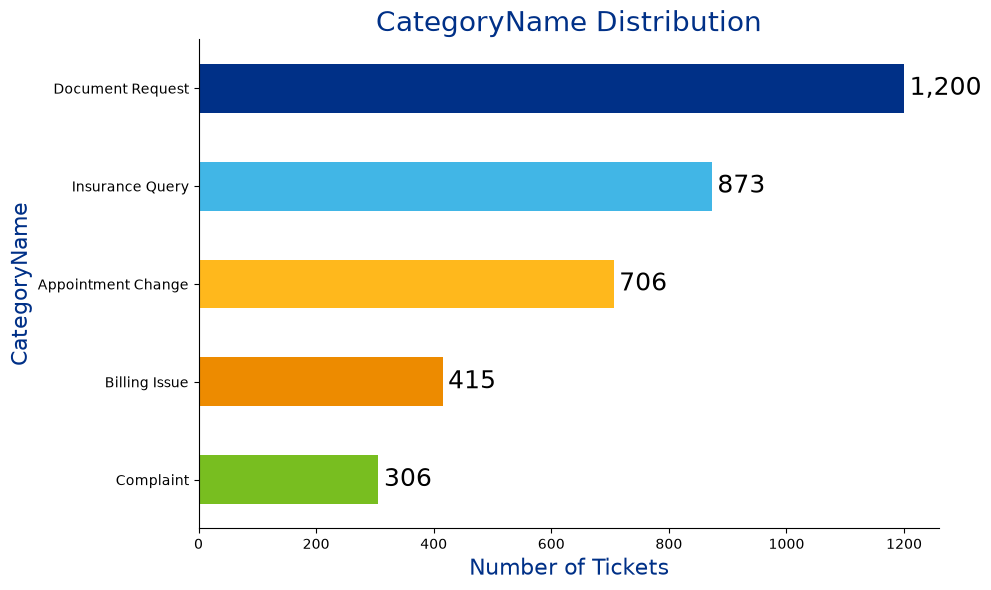

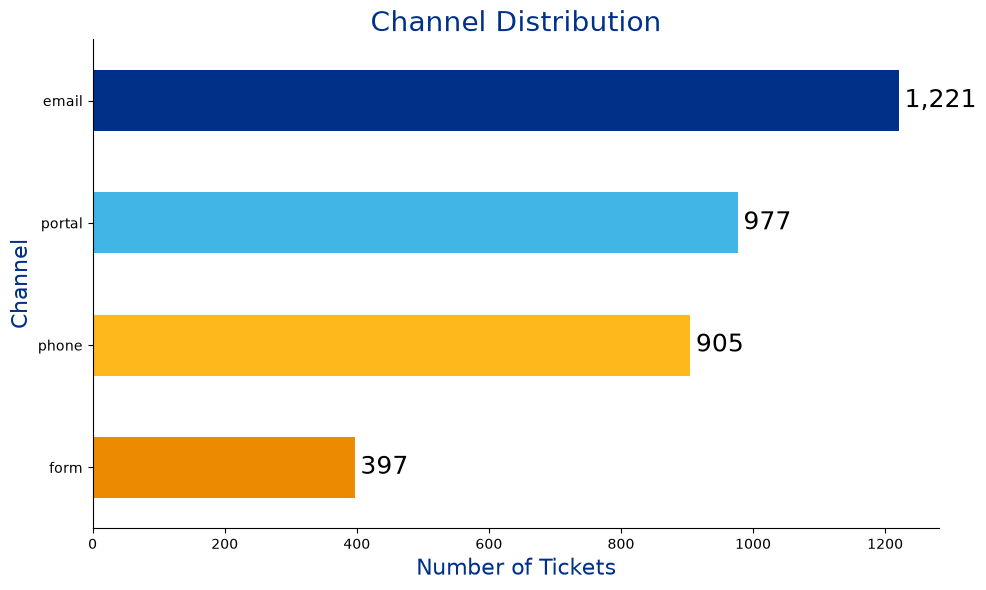

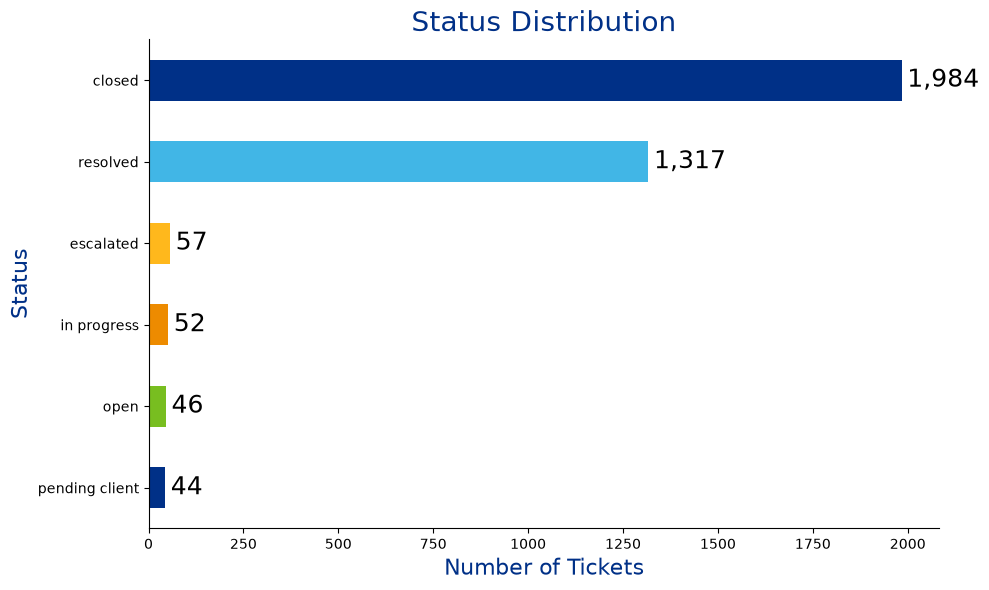

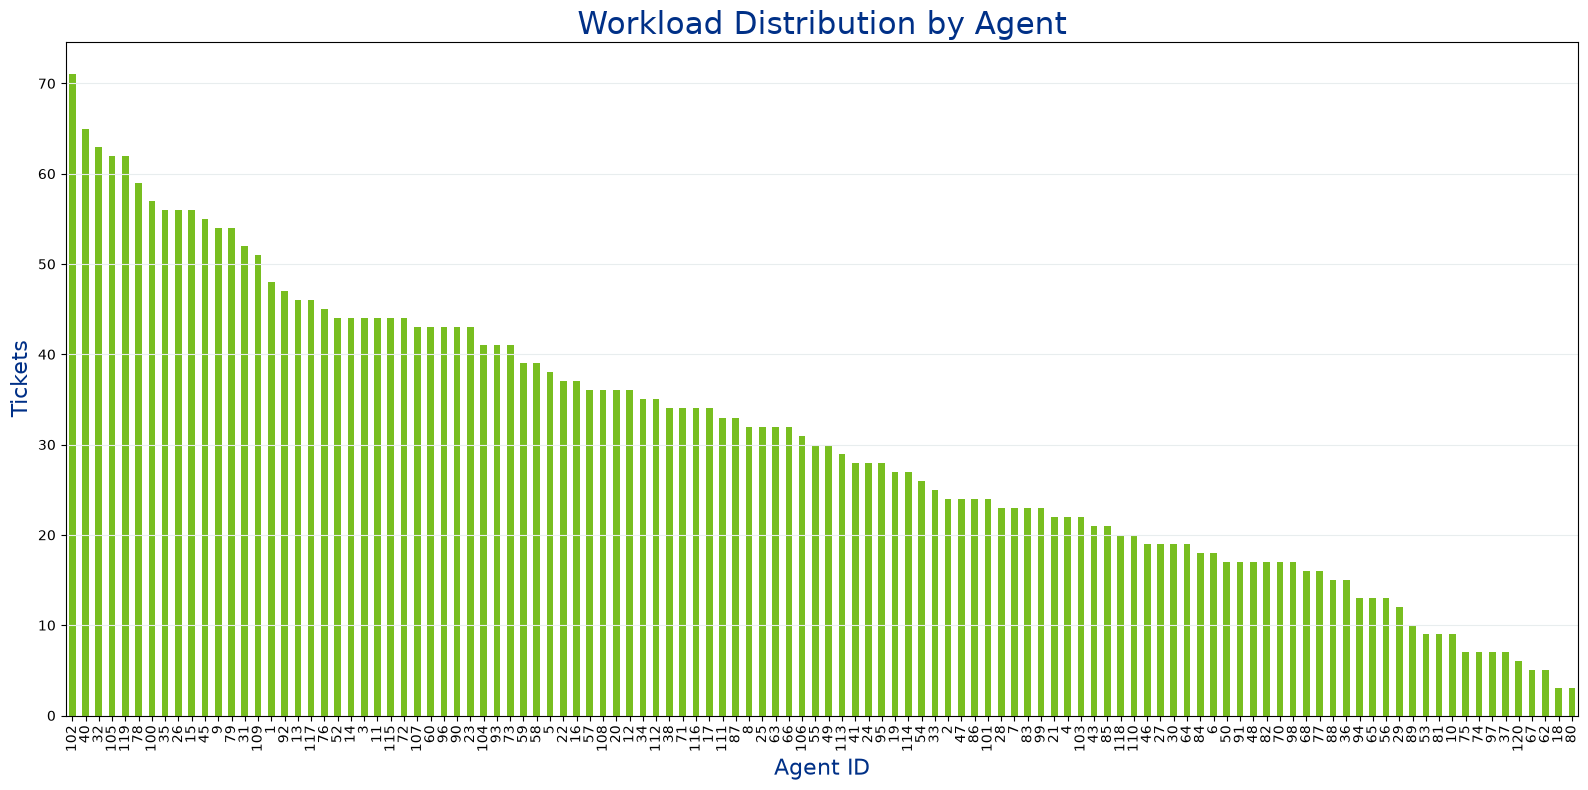

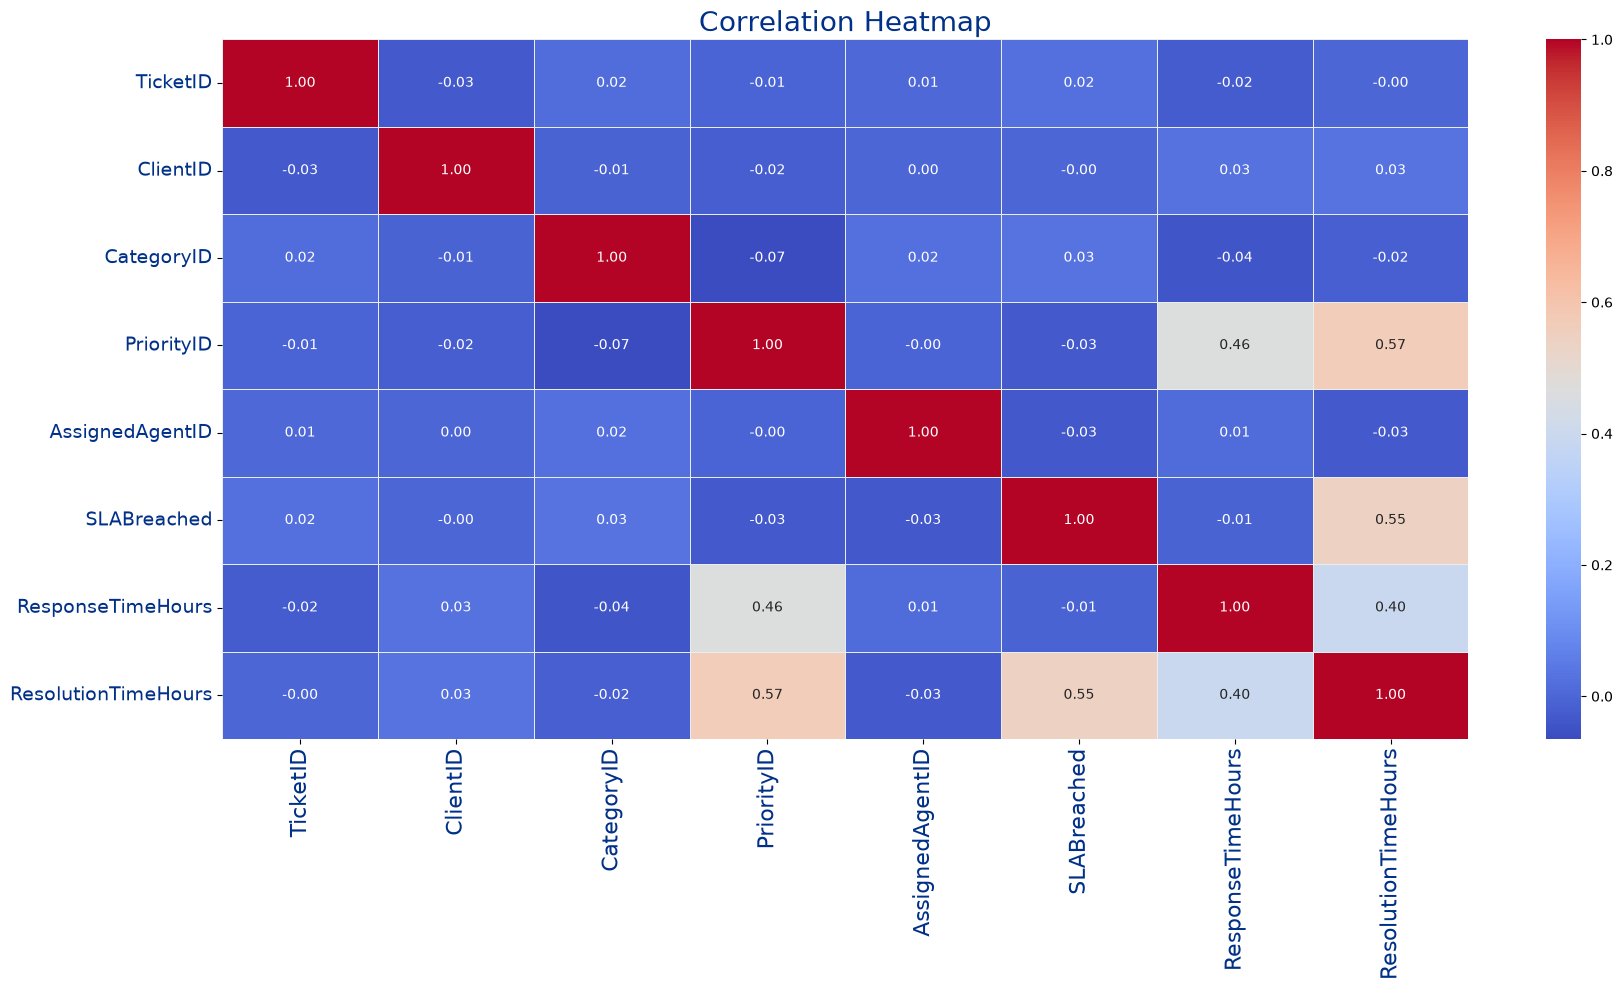

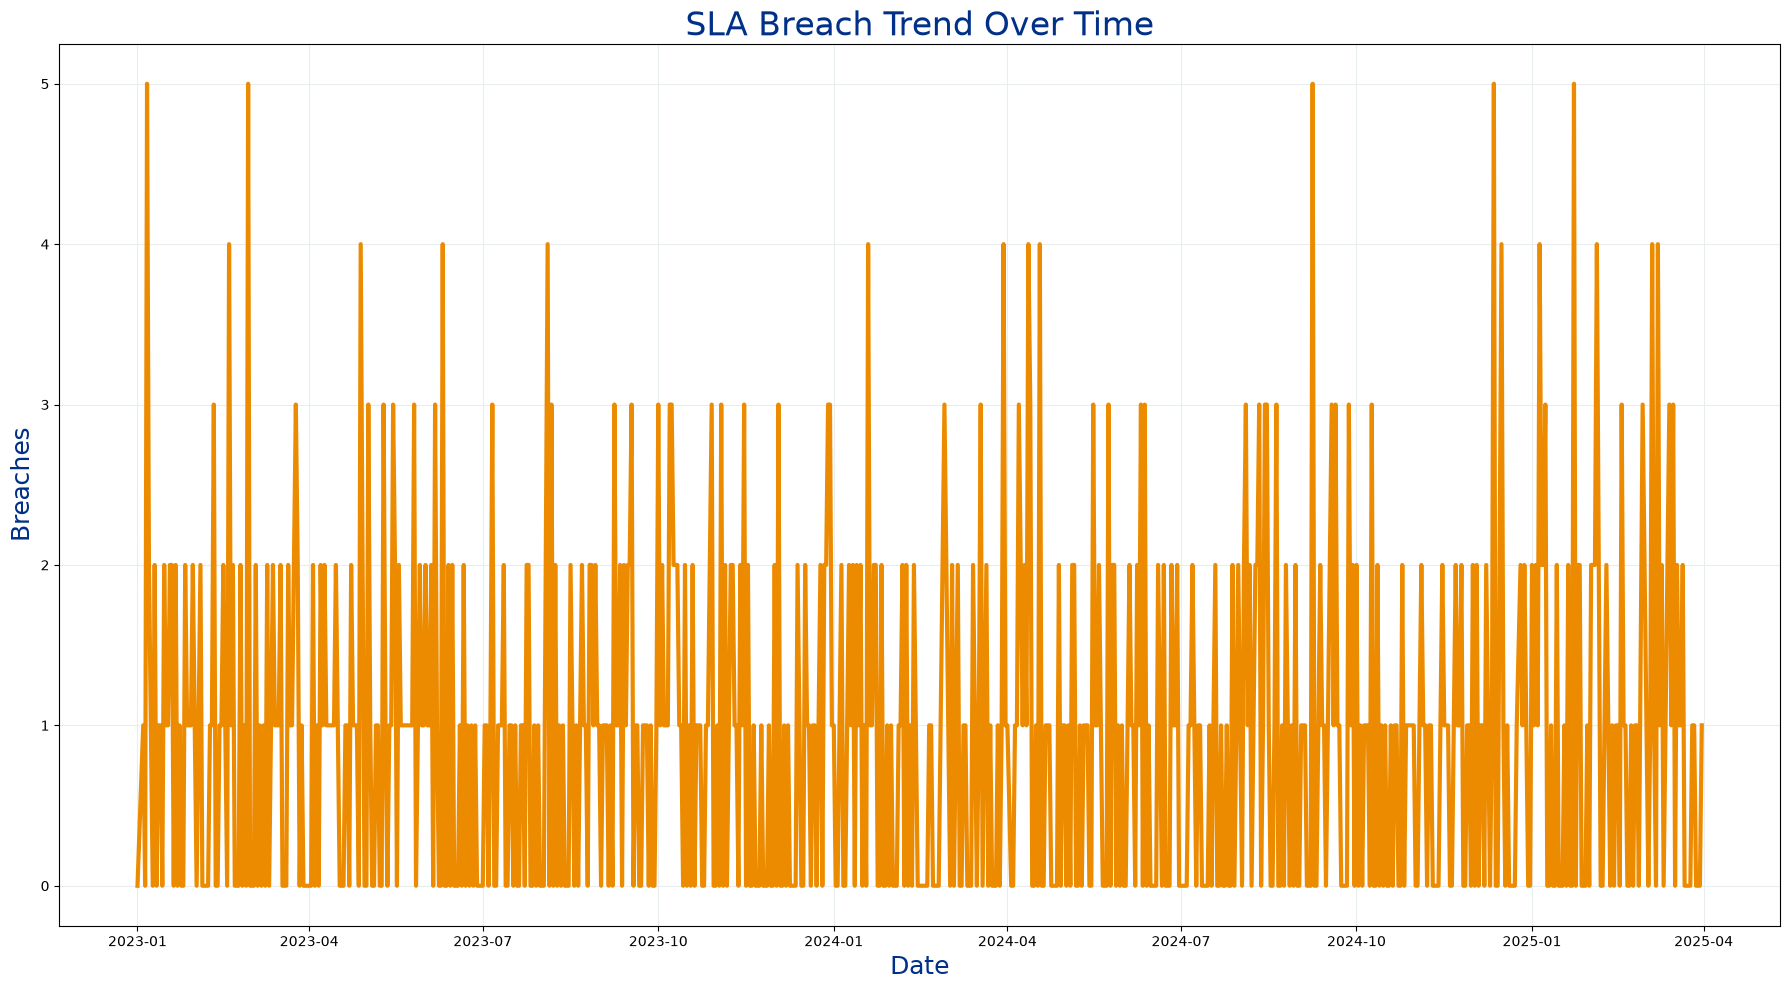

In [54]:
# 1. Create lookup dictionaries
category_map = {
    1: "Document Request",
    2: "Insurance Query",
    3: "Appointment Change",
    4: "Complaint",
    5: "Billing Issue"
}

priority_map = {
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Critical"
}

# 2. Create readable columns FIRST
tickets["CategoryName"] = tickets["CategoryID"].map(category_map)
tickets["PriorityLabel"] = tickets["PriorityID"].map(priority_map)

# 3. THEN plot using the new readable columns
def plot_category_counts(df, column):
    if column not in df.columns:
        return

    counts = df[column].value_counts()

    palette = [
        colors["nhs_dark_blue"],
        colors["nhs_light_blue"],
        colors["warm_yellow"],
        colors["orange"],
        colors["light_green"],
    ]

    bar_colors = (palette * (len(counts) // len(palette) + 1))[:len(counts)]

    plt.figure(figsize=(10, 6))
    ax = counts.plot(kind="barh", color=bar_colors)

    plt.title(
        f"{column} Distribution",
        fontsize=20,
        color=colors["nhs_dark_blue"]
    )
    plt.xlabel(
        "Number of Tickets",
        fontsize=16,
        color=colors["nhs_dark_blue"]
    )
    plt.ylabel(
        column,
        fontsize=16,
        color=colors["nhs_dark_blue"]
    )

    ax.grid(False)
    ax.invert_yaxis()
    ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=4, fontsize=18)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()
plot_category_counts(tickets, "CategoryName")

# 4. Other plots remain the same
plot_category_counts(tickets, "Channel")
plot_category_counts(tickets, "Status")

plot_workload(tickets)
plot_correlation(tickets)
plot_sla_trend(tickets)


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\NorthBridge_Health\Data\NorthBridgeDataset.xlsx"

# Load all sheets at once into a dictionary
sheets = pd.read_excel(file_path, sheet_name=None)

# Print sheet names
print("Sheets found in the Excel file:")
print(list(sheets.keys()))

# Load individual sheets
tickets = sheets["Tickets"]
clients = sheets["Clients"]
agents = sheets["Agents"]
audit = sheets["TicketAuditLog"]
escalations = sheets["EscalationLog"]

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)


Sheets found in the Excel file:
['README', 'PriorityLevels', 'TicketCategories', 'SLADefinitions', 'Agents', 'Clients', 'Tickets', 'TicketAuditLog', 'EscalationLog']


Priority Distribution.
Priority 3 → 1,981 tickets Priority 3 dominates the workload (56.6% of all tickets)
Priority 2 → 833 tickets Priority 2 is the second largest group (23.8%)
Priority 4 → 428 tickets Priority 4 is relatively small (12.2%)
Priority 1 → 258 tickets Priority 1 is the smallest group (7.3%)


CatergoryID by Distribution 
- Category 1 dominates the workload (34.3% of all tickets) - Most agent time is spent on Category 1;SLA breaches will be heavily influenced by Category 1 behaviour
- Category 2 is the second‑largest group (24.9%)

### RESPONSE AND RESOLUTION TIME ANALYSIS

In [55]:
tickets["CreatedAt"] = pd.to_datetime(tickets["CreatedAt"], errors="coerce")
tickets["FirstResponseAt"] = pd.to_datetime(tickets["FirstResponseAt"], errors="coerce")
tickets["ResolvedAt"] = pd.to_datetime(tickets["ResolvedAt"], errors="coerce")
tickets["SLADueAt"] = pd.to_datetime(tickets["SLADueAt"], errors="coerce")


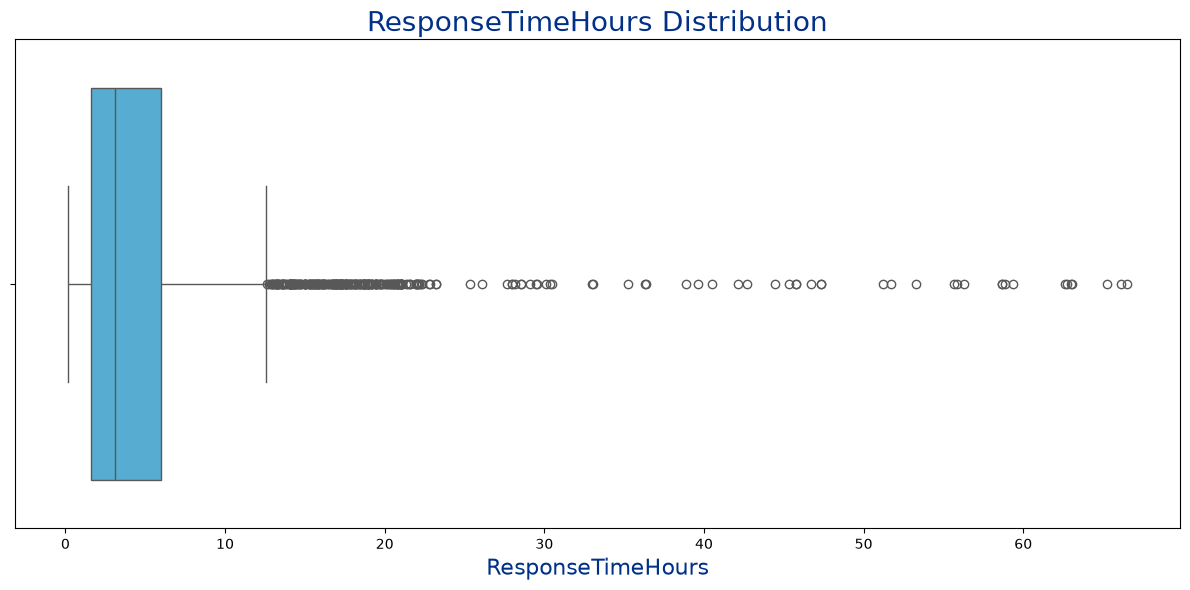

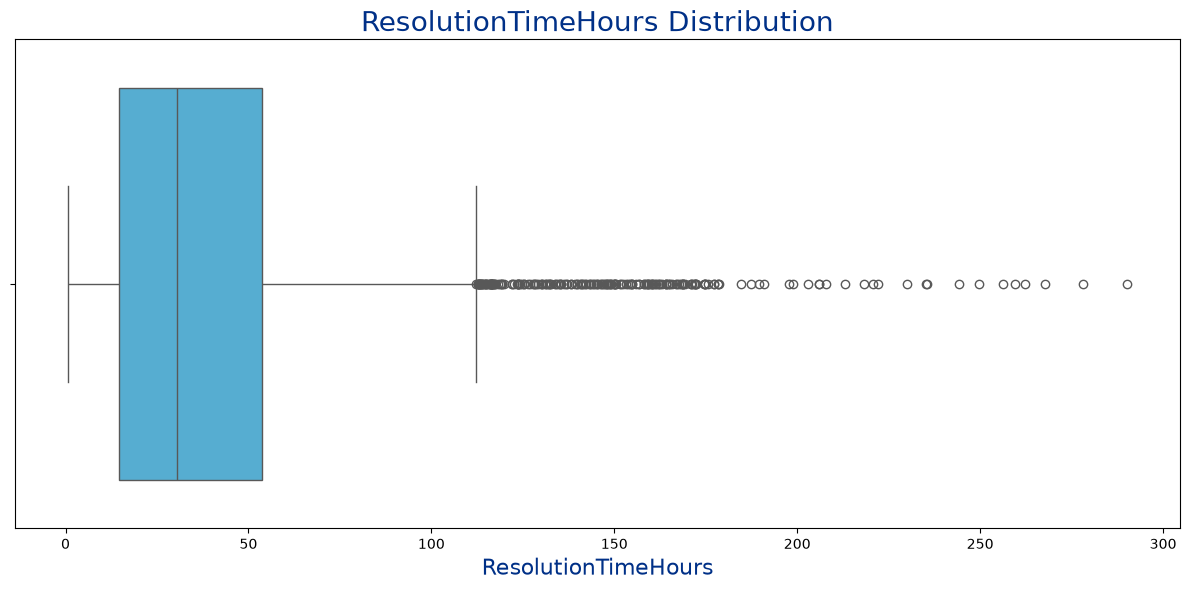

In [56]:
tickets["ResponseTimeHours"] = (
    (tickets["FirstResponseAt"] - tickets["CreatedAt"]).dt.total_seconds() / 3600
)

tickets["ResolutionTimeHours"] = (
    (tickets["ResolvedAt"] - tickets["CreatedAt"]).dt.total_seconds() / 3600
)

def plot_time_distribution(df, column):
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x=column, color=colors["nhs_light_blue"])
    plt.title(f"{column} Distribution", fontsize=20, color=colors["nhs_dark_blue"])
    plt.xlabel(column, fontsize=16, color=colors["nhs_dark_blue"])
    plt.tight_layout()
    plt.show()

plot_time_distribution(tickets, "ResponseTimeHours")
plot_time_distribution(tickets, "ResolutionTimeHours")


Observation:  Response time.
Most response times are clustered tightly at the lower end (fast responses).
There are many outliers, some reaching 60+ hours.
The distribution is right‑skewed, meaning a small number of tickets take much longer to respond.
Operational meaning
The service responds quickly most of the time.
But inconsistent response times exist — these long delays likely contribute to SLA breaches.


Observation: ResolutionTimeHours.
The chart shows; Most tickets are resolved within 60 hours.
There are extreme outliers reaching 200–300 hours.
Distribution is heavily right‑skewed.
Operational meaning
Resolution time varies widely. 
Long resolution times are likely tied to: complex categories
overloaded agents, escalations, poor client responsiveness



### AGENT PERFORMANACE

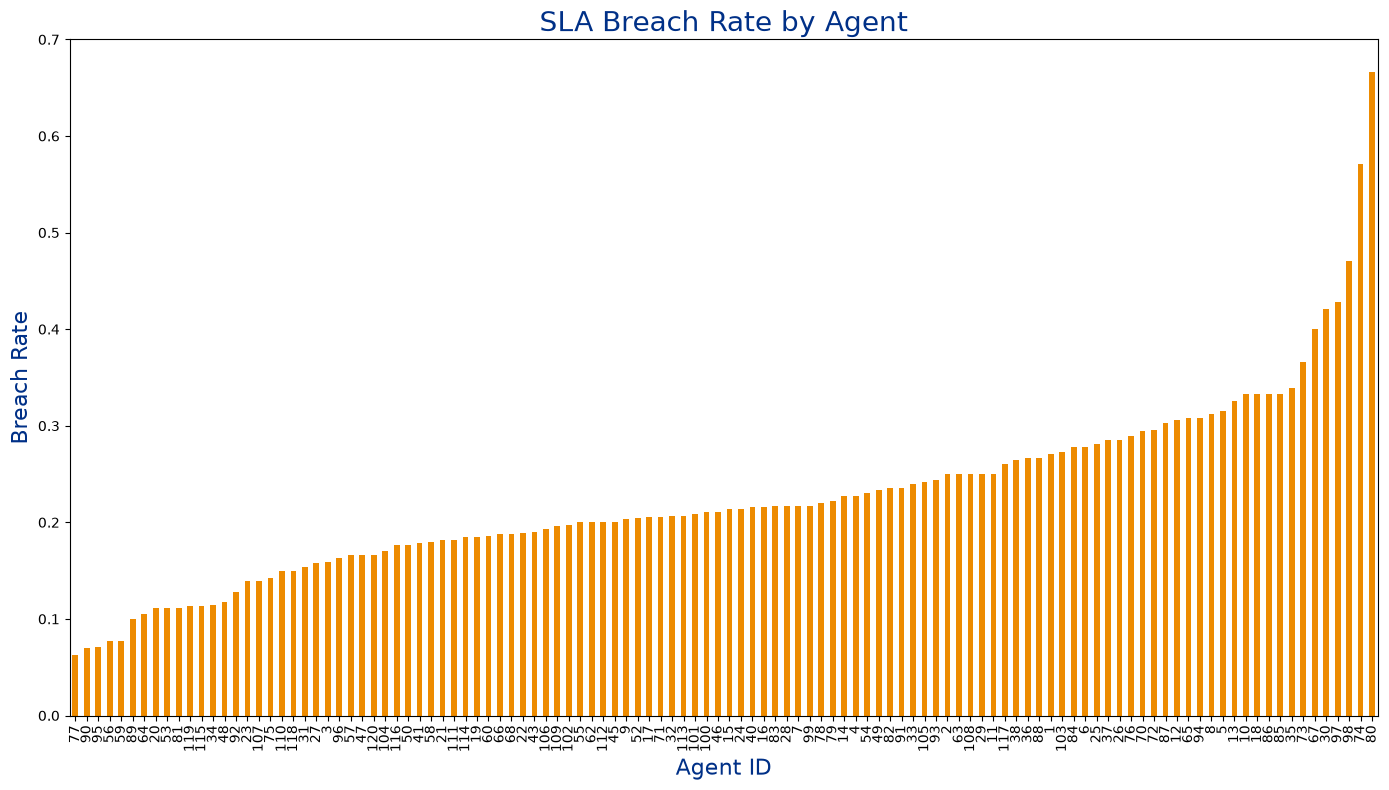

In [57]:
agent_sla = tickets.groupby("AssignedAgentID")["SLABreached"].mean()

plt.figure(figsize=(14, 8))
agent_sla.sort_values().plot(kind="bar", color=colors["orange"])
plt.title("SLA Breach Rate by Agent", fontsize=20, color=colors["nhs_dark_blue"])
plt.xlabel("Agent ID", fontsize=16, color=colors["nhs_dark_blue"])
plt.ylabel("Breach Rate", fontsize=16, color=colors["nhs_dark_blue"])
plt.tight_layout()
plt.show()


### Client Performance Analysis

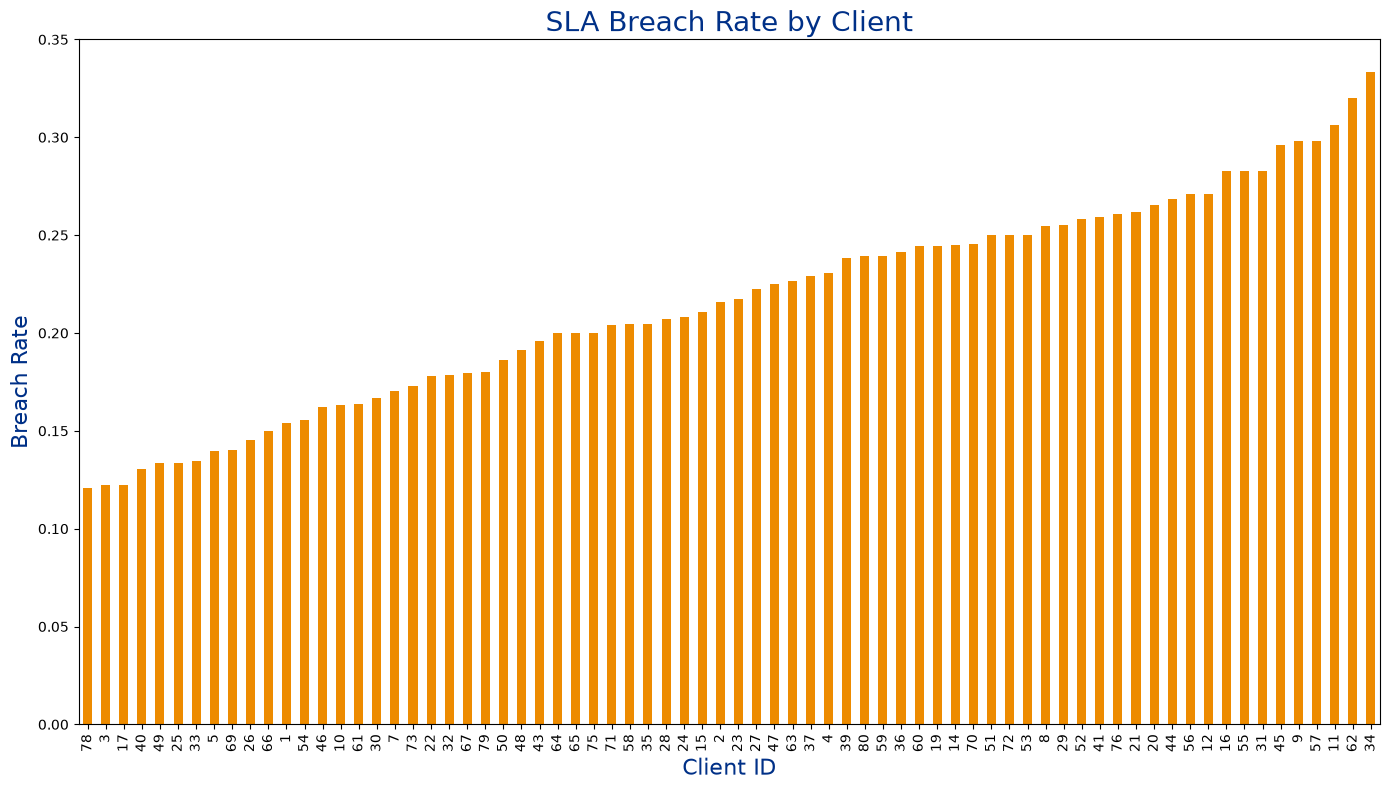

In [58]:
client_sla = tickets.groupby("ClientID")["SLABreached"].mean()

plt.figure(figsize=(14, 8))
client_sla.sort_values().plot(kind="bar", color=colors["orange"])
plt.title("SLA Breach Rate by Client", fontsize=20, color=colors["nhs_dark_blue"])
plt.xlabel("Client ID", fontsize=16, color=colors["nhs_dark_blue"])
plt.ylabel("Breach Rate", fontsize=16, color=colors["nhs_dark_blue"])
plt.tight_layout()
plt.show()


### Monthly Trend Analysis

In [59]:
tickets["CreatedAt"] = pd.to_datetime(tickets["CreatedAt"], errors="coerce")
tickets["FirstResponseAt"] = pd.to_datetime(tickets["FirstResponseAt"], errors="coerce")
tickets["ResolvedAt"] = pd.to_datetime(tickets["ResolvedAt"], errors="coerce")
tickets["SLADueAt"] = pd.to_datetime(tickets["SLADueAt"], errors="coerce")


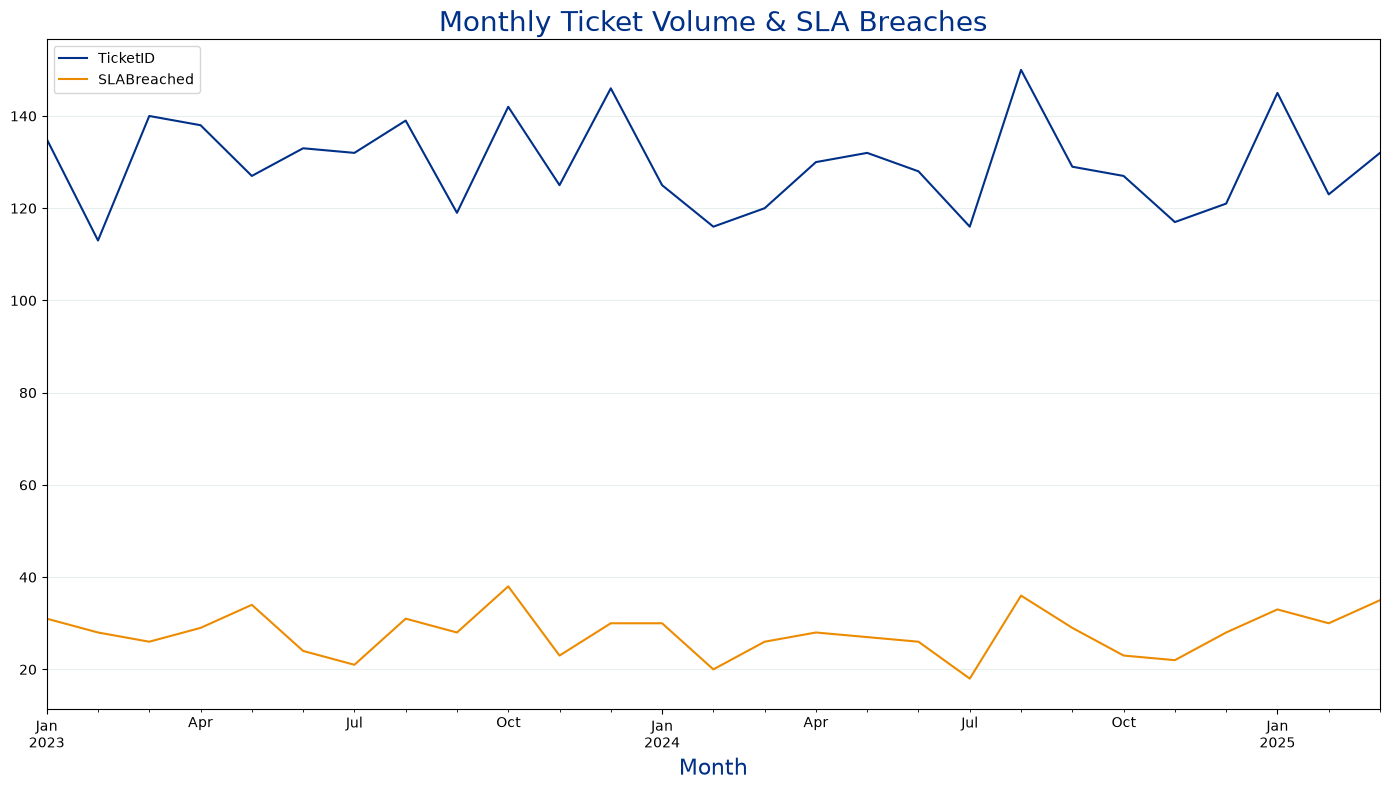

In [60]:
tickets["Month"] = tickets["CreatedAt"].dt.to_period("M")

monthly = tickets.groupby("Month").agg({
    "TicketID": "count",
    "SLABreached": "sum"
})

monthly.plot(figsize=(14, 8), color=[colors["nhs_dark_blue"], colors["orange"]])
plt.title("Monthly Ticket Volume & SLA Breaches", fontsize=20, color=colors["nhs_dark_blue"])
plt.xlabel("Month", fontsize=16, color=colors["nhs_dark_blue"])
plt.grid(axis="y", color=colors["pale_grey"])
plt.tight_layout()
plt.show()


In [61]:
category_map = {
    1: "Document Request",
    2: "Insurance Query",
    3: "Appointment Change",
    4: "Complaint",
    5: "Billing Issue"
}

priority_map = {
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Critical"
}

tickets["CategoryName"] = tickets["CategoryID"].map(category_map)
tickets["PriorityLabel"] = tickets["PriorityID"].map(priority_map)


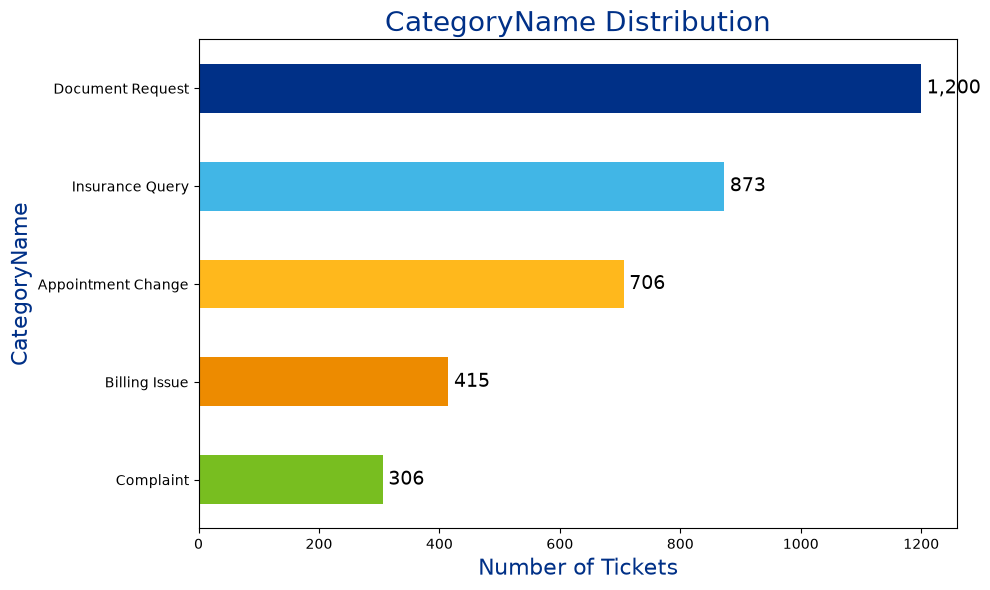

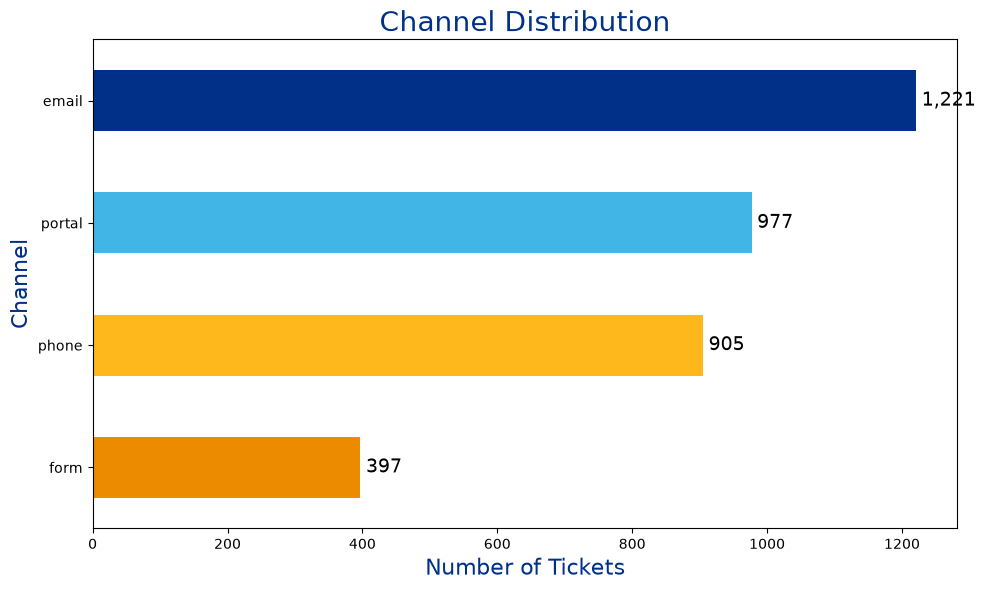

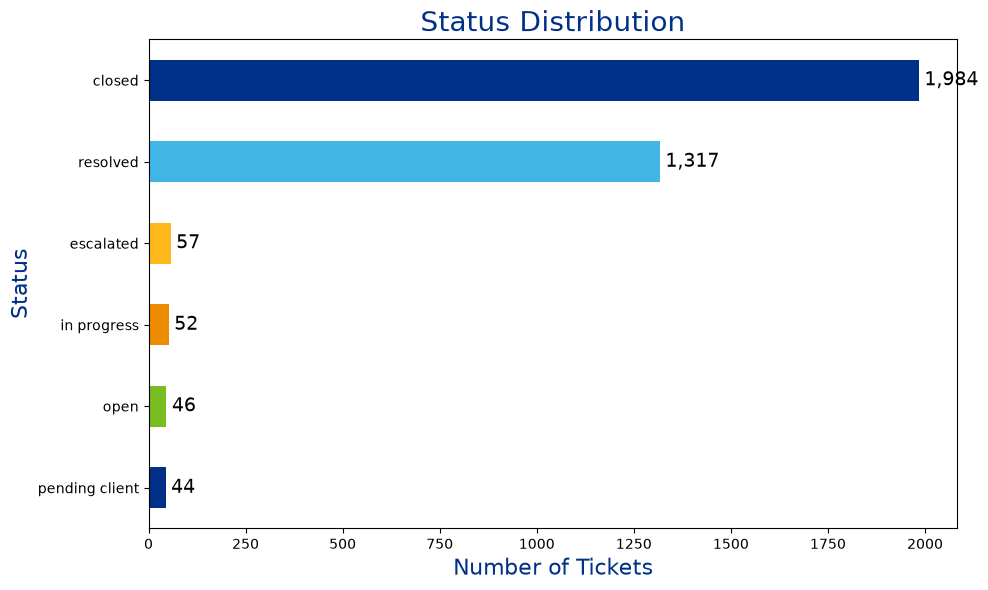

In [62]:
def plot_category_counts(df, column):
    counts = df[column].value_counts()

    palette = [
        colors["nhs_dark_blue"],
        colors["nhs_light_blue"],
        colors["warm_yellow"],
        colors["orange"],
        colors["light_green"],
    ]

    bar_colors = (palette * (len(counts) // len(palette) + 1))[:len(counts)]

    plt.figure(figsize=(10, 6))
    ax = counts.plot(kind="barh", color=bar_colors)

    plt.title(f"{column} Distribution", fontsize=20, color=colors["nhs_dark_blue"])
    plt.xlabel("Number of Tickets", fontsize=16, color=colors["nhs_dark_blue"])
    plt.ylabel(column, fontsize=16, color=colors["nhs_dark_blue"])

    ax.grid(False)
    ax.invert_yaxis()
    ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=4, fontsize=14)

    plt.tight_layout()
    plt.show()

plot_category_counts(tickets, "CategoryName")
plot_category_counts(tickets, "Channel")
plot_category_counts(tickets, "Status")


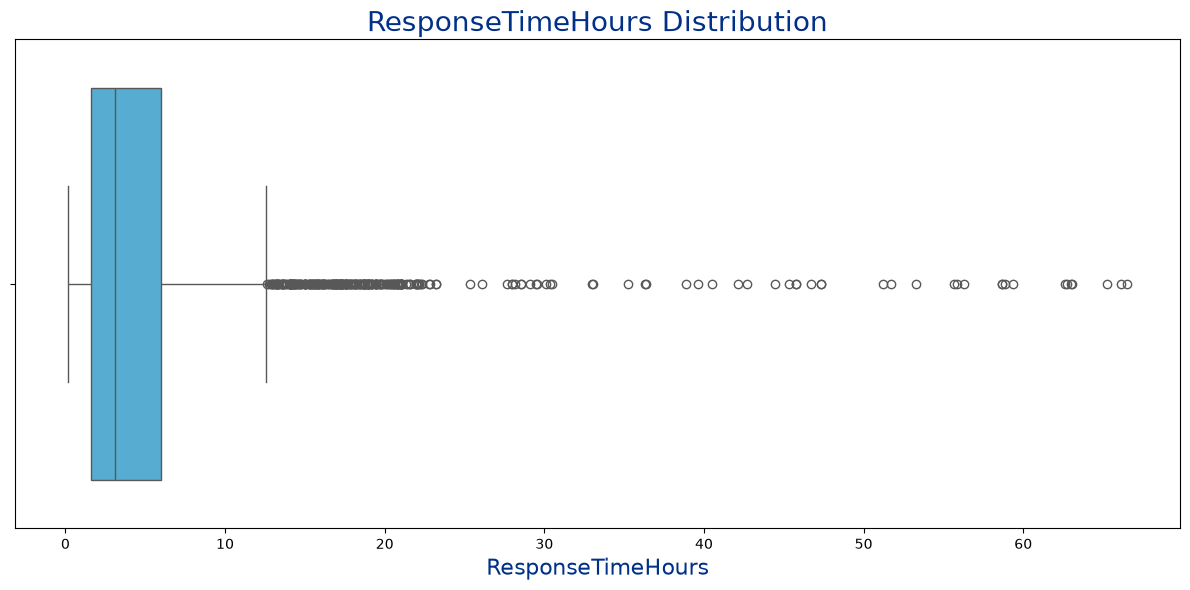

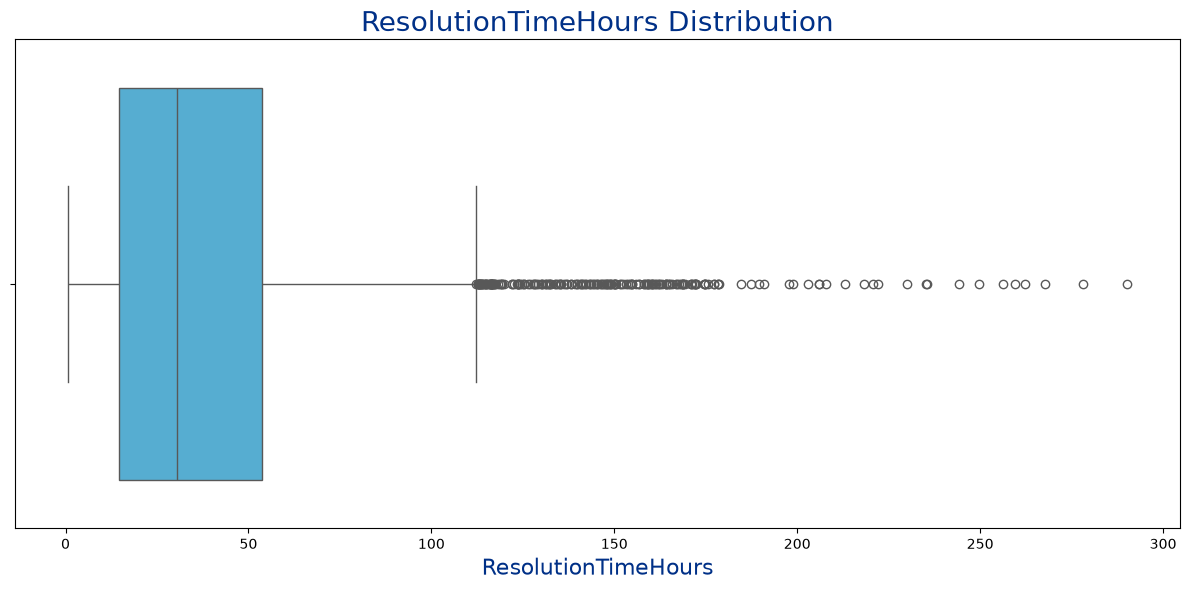

In [63]:
tickets["ResponseTimeHours"] = (
    (tickets["FirstResponseAt"] - tickets["CreatedAt"]).dt.total_seconds() / 3600
)

tickets["ResolutionTimeHours"] = (
    (tickets["ResolvedAt"] - tickets["CreatedAt"]).dt.total_seconds() / 3600
)

def plot_time_distribution(df, column):
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x=column, color=colors["nhs_light_blue"])
    plt.title(f"{column} Distribution", fontsize=20, color=colors["nhs_dark_blue"])
    plt.xlabel(column, fontsize=16, color=colors["nhs_dark_blue"])
    plt.tight_layout()
    plt.show()

plot_time_distribution(tickets, "ResponseTimeHours")
plot_time_distribution(tickets, "ResolutionTimeHours")


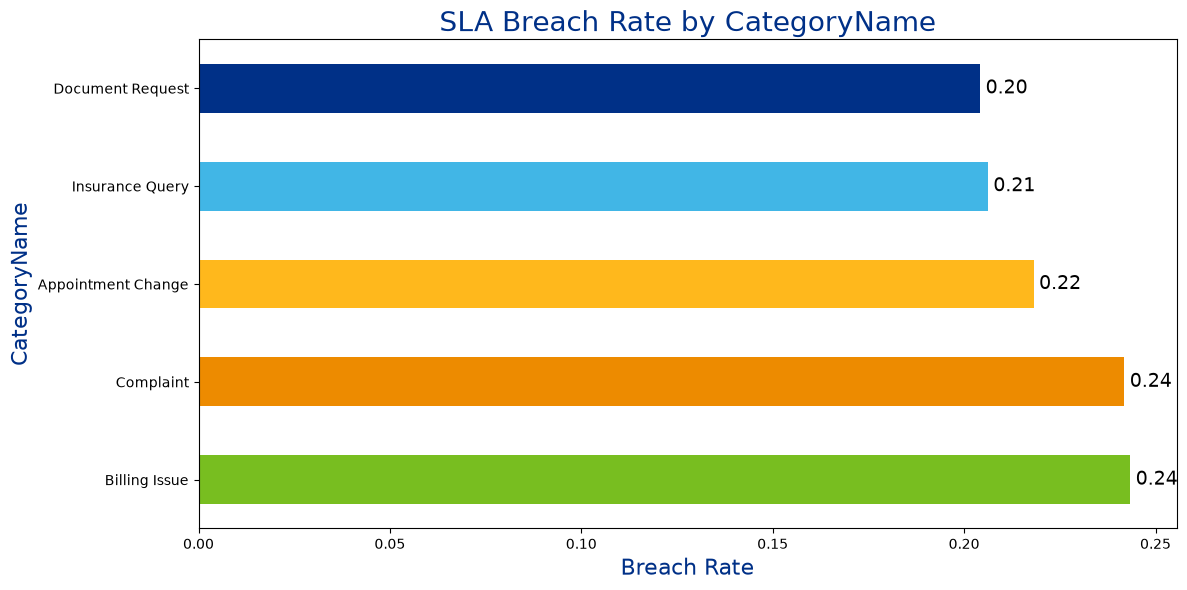

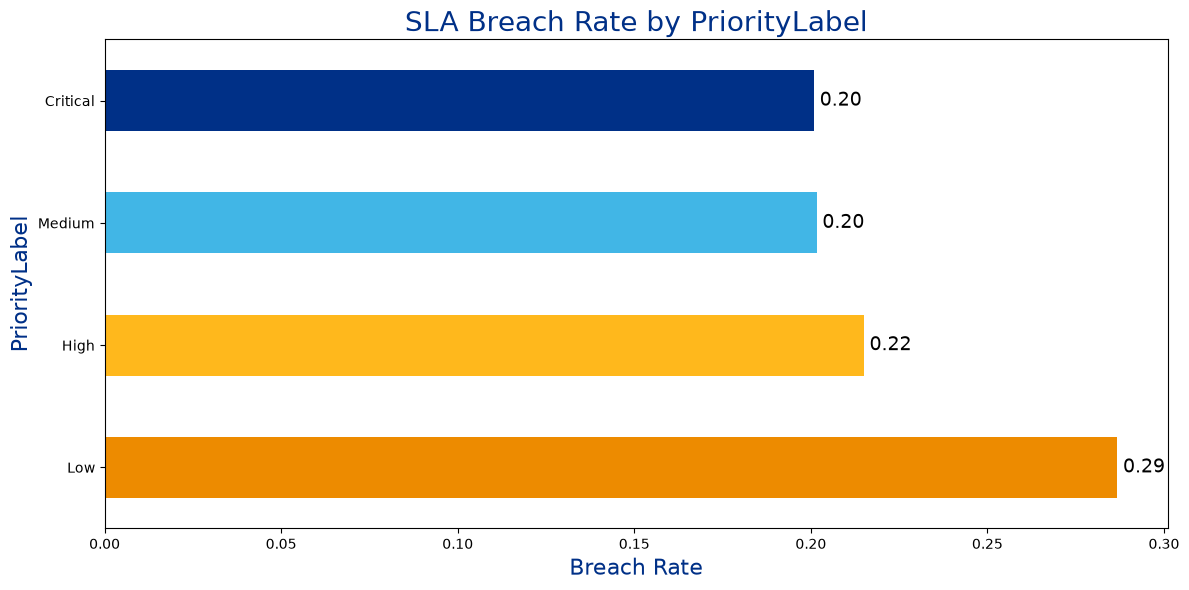

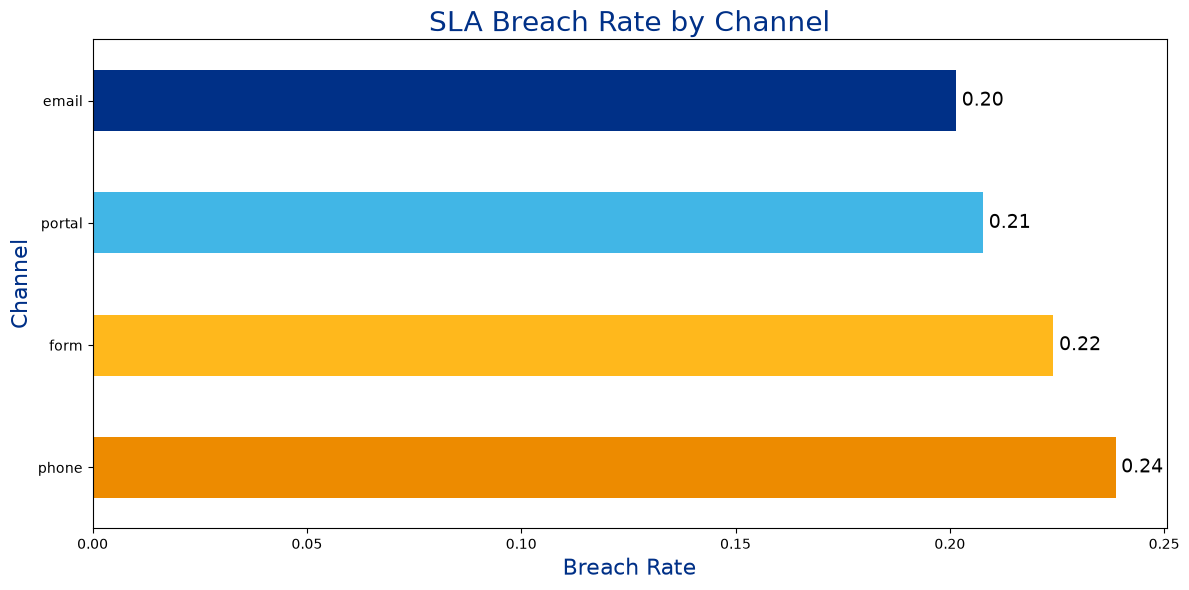

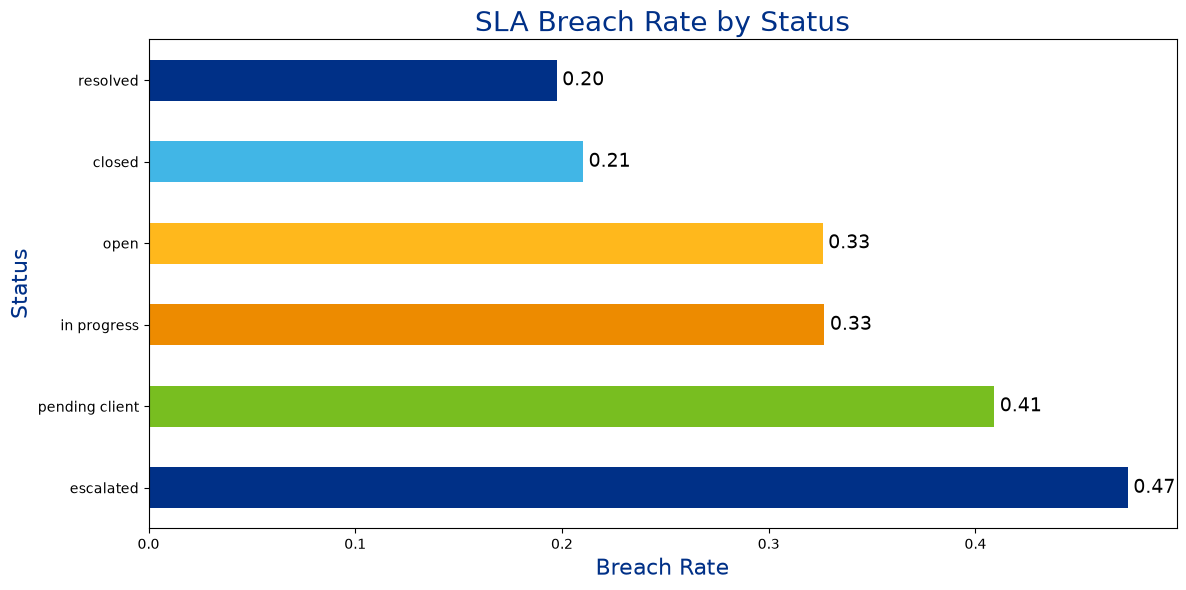

In [64]:
def plot_sla_by_column(df, column):
    sla_rates = df.groupby(column)["SLABreached"].mean().sort_values()

    palette = [
        colors["nhs_dark_blue"],
        colors["nhs_light_blue"],
        colors["warm_yellow"],
        colors["orange"],
        colors["light_green"],
    ]

    bar_colors = (palette * (len(sla_rates) // len(palette) + 1))[:len(sla_rates)]

    plt.figure(figsize=(12, 6))
    ax = sla_rates.plot(kind="barh", color=bar_colors)

    plt.title(f"SLA Breach Rate by {column}", fontsize=20, color=colors["nhs_dark_blue"])
    plt.xlabel("Breach Rate", fontsize=16, color=colors["nhs_dark_blue"])
    plt.ylabel(column, fontsize=16, color=colors["nhs_dark_blue"])

    ax.grid(False)
    ax.invert_yaxis()
    ax.bar_label(ax.containers[0], fmt="{:.2f}", padding=4, fontsize=14)

    plt.tight_layout()
    plt.show()

plot_sla_by_column(tickets, "CategoryName")
plot_sla_by_column(tickets, "PriorityLabel")
plot_sla_by_column(tickets, "Channel")
plot_sla_by_column(tickets, "Status")


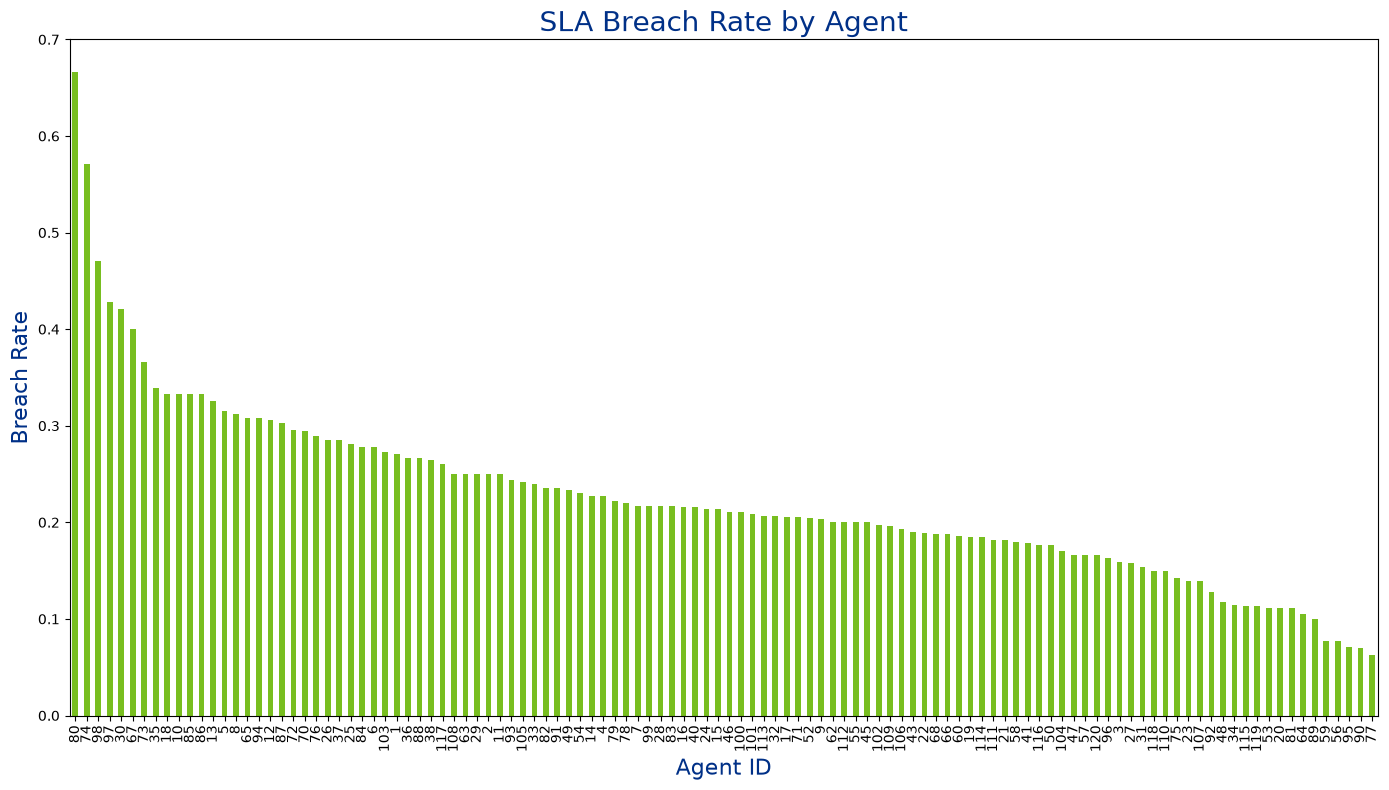

In [65]:
agent_sla = tickets.groupby("AssignedAgentID")["SLABreached"].mean()

plt.figure(figsize=(14, 8))
agent_sla.sort_values(ascending=False).plot(kind="bar", color=colors["light_green"])
plt.title("SLA Breach Rate by Agent", fontsize=20, color=colors["nhs_dark_blue"])
plt.xlabel("Agent ID", fontsize=16, color=colors["nhs_dark_blue"])
plt.ylabel("Breach Rate", fontsize=16, color=colors["nhs_dark_blue"])
plt.tight_layout()
plt.show()


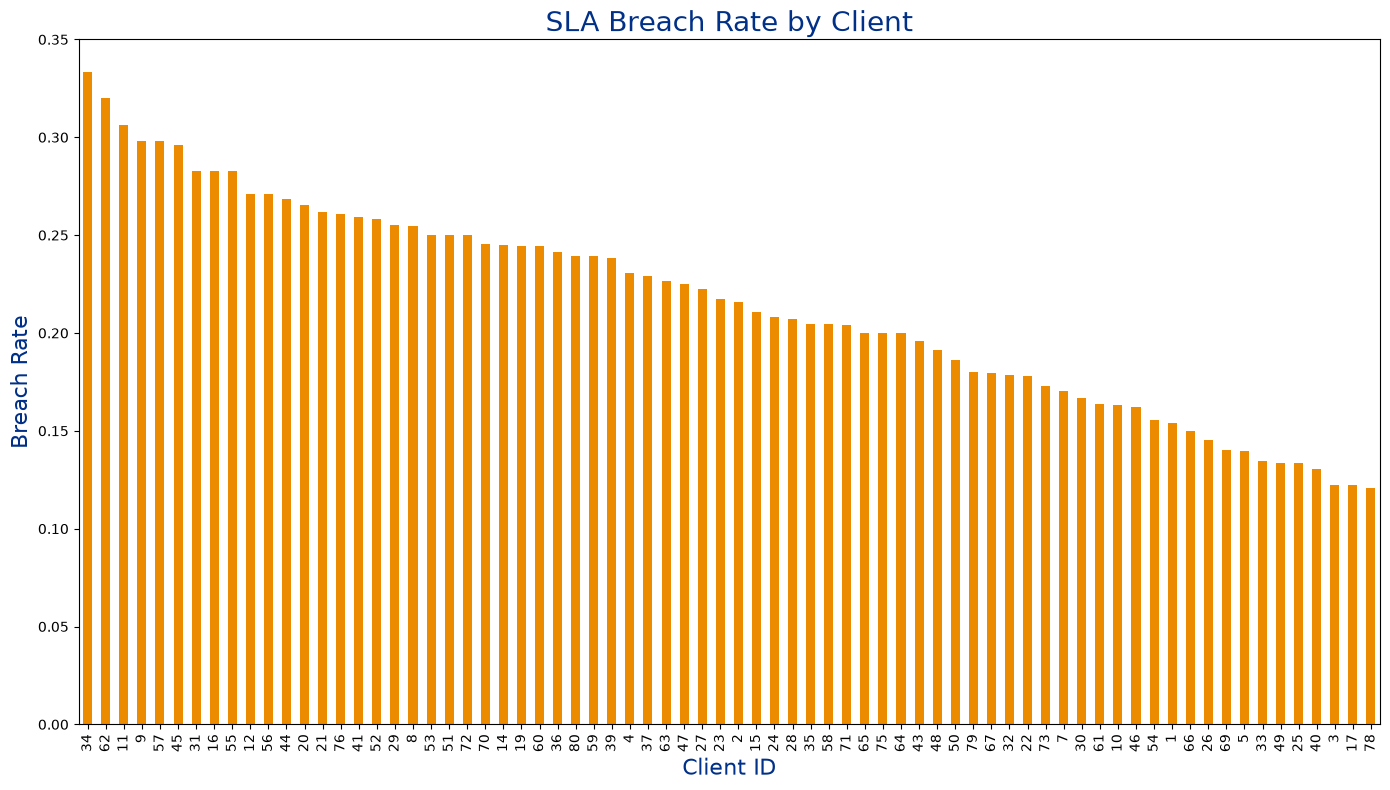

In [66]:
client_sla = tickets.groupby("ClientID")["SLABreached"].mean()

plt.figure(figsize=(14, 8))
client_sla.sort_values(ascending=False).plot(kind="bar", color=colors["orange"])
plt.title("SLA Breach Rate by Client", fontsize=20, color=colors["nhs_dark_blue"])
plt.xlabel("Client ID", fontsize=16, color=colors["nhs_dark_blue"])
plt.ylabel("Breach Rate", fontsize=16, color=colors["nhs_dark_blue"])
plt.tight_layout()
plt.show()


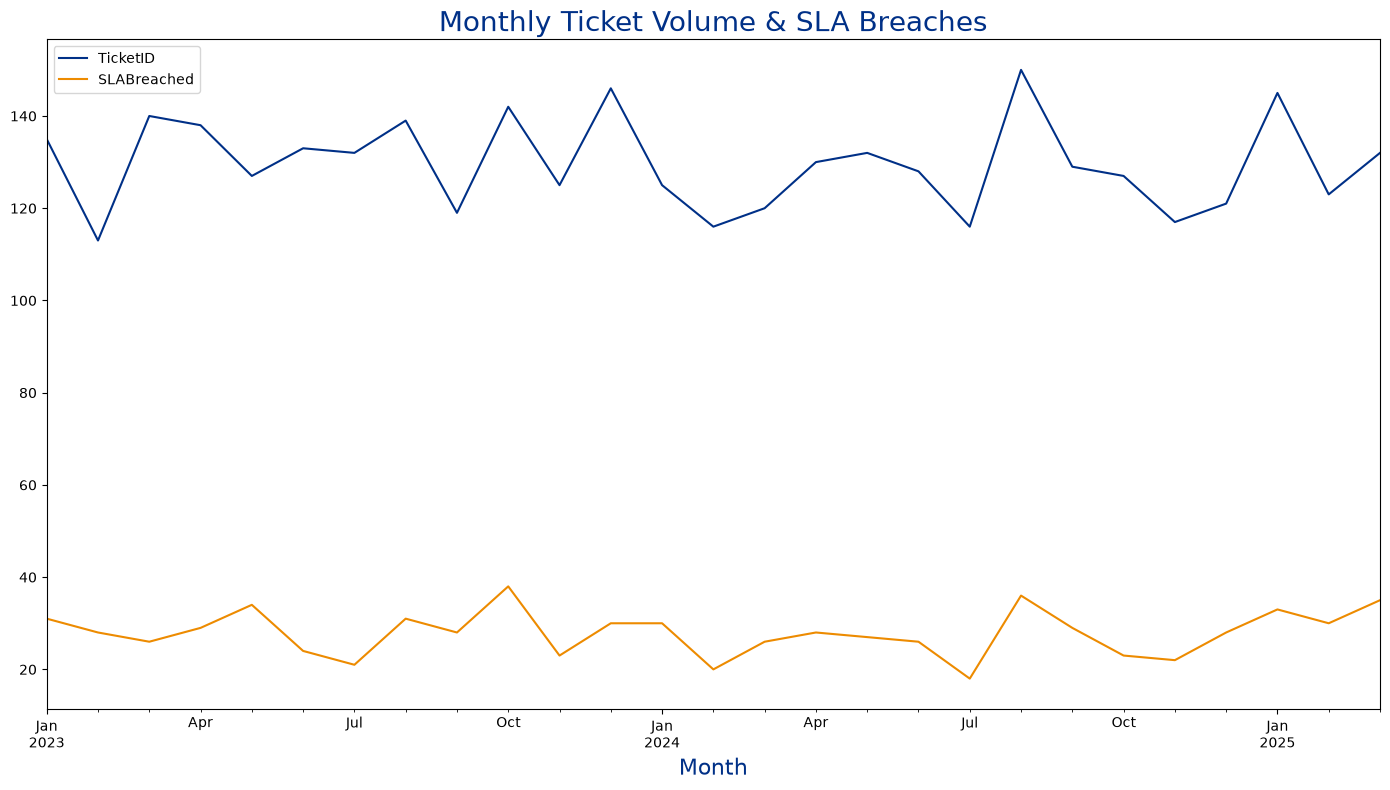

In [67]:
tickets["Month"] = tickets["CreatedAt"].dt.to_period("M")

monthly = tickets.groupby("Month").agg({
    "TicketID": "count",
    "SLABreached": "sum"
})

monthly.plot(figsize=(14, 8), color=[colors["nhs_dark_blue"], colors["orange"]])
plt.title("Monthly Ticket Volume & SLA Breaches", fontsize=20, color=colors["nhs_dark_blue"])
plt.xlabel("Month", fontsize=16, color=colors["nhs_dark_blue"])
plt.tight_layout()
plt.show()


In [68]:
from collections import Counter
import re

def extract_keywords(text_series):
    words = " ".join(text_series).lower()
    words = re.findall(r"[a-zA-Z]{4,}", words)
    return Counter(words).most_common(20)

top_desc_words = extract_keywords(tickets["Description"])
top_res_words = extract_keywords(tickets["ResolutionNotes"])

pd.DataFrame(top_desc_words, columns=["Word", "Frequency"])
pd.DataFrame(top_res_words, columns=["Word", "Frequency"])


,Word,Frequency
0,patient,1319
1,following,1185
2,appointment,1127
3,sent,934
4,client,868
5,insurer,661
6,updated,654
7,within,561
8,confirmation,491
9,from,475


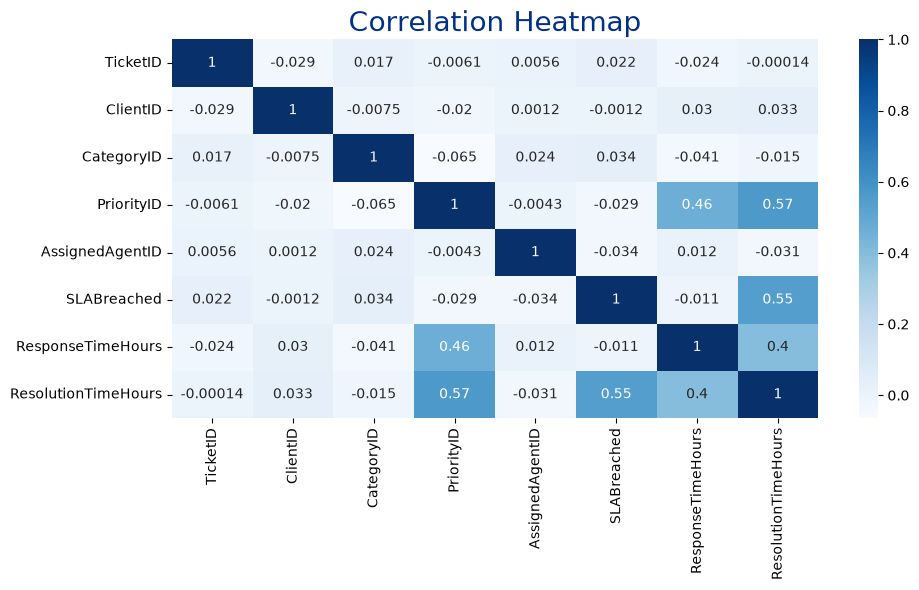

In [69]:
plt.figure(figsize=(10, 6))
sns.heatmap(tickets.corr(numeric_only=True), annot=True, cmap="Blues")
plt.title("Correlation Heatmap", fontsize=20, color=colors["nhs_dark_blue"])
plt.tight_layout()
plt.show()


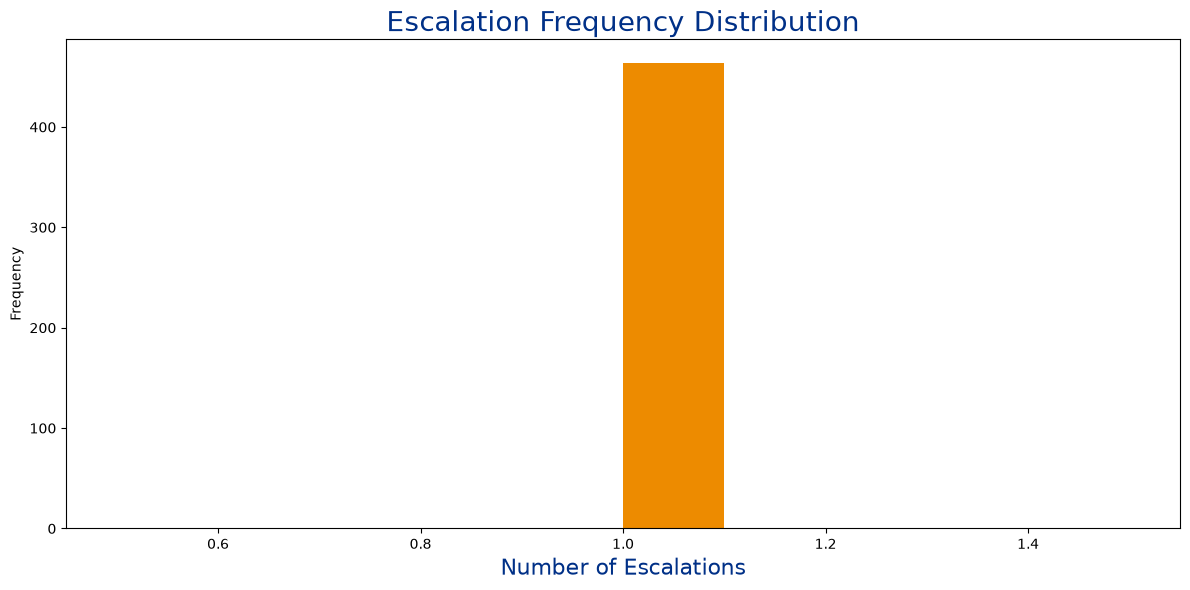

In [70]:
# Count escalations per ticket
esc_counts = escalations.groupby("TicketID").size()

plt.figure(figsize=(12, 6))
esc_counts.plot(kind="hist", bins=10, color=colors["orange"])
plt.title("Escalation Frequency Distribution", fontsize=20, color=colors["nhs_dark_blue"])
plt.xlabel("Number of Escalations", fontsize=16, color=colors["nhs_dark_blue"])
plt.tight_layout()
plt.show()


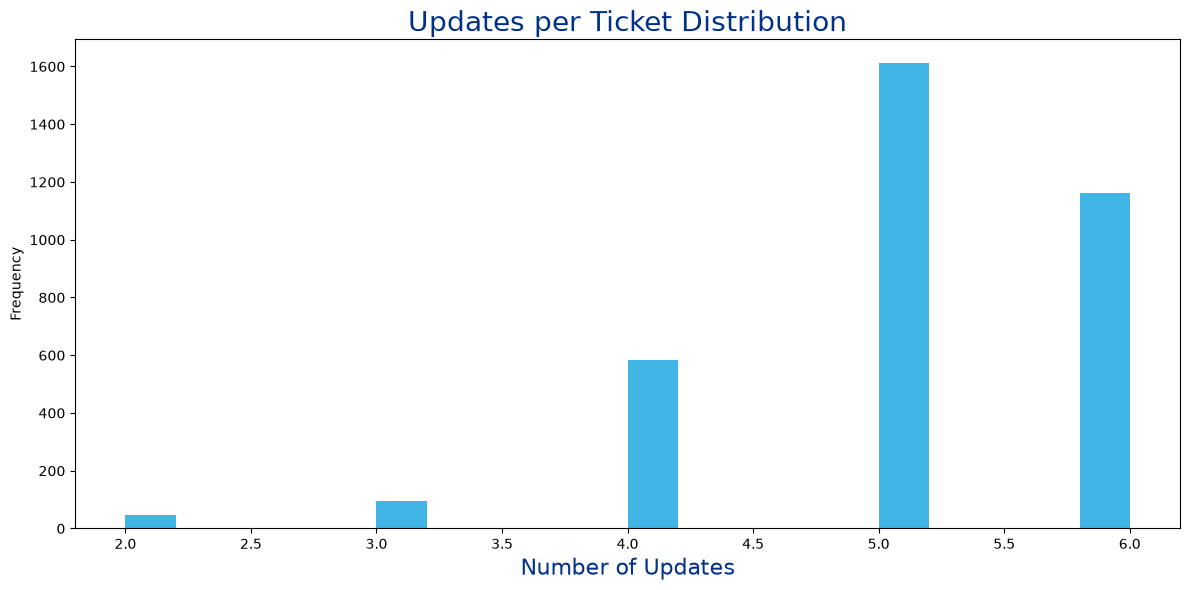

In [71]:
# Count updates per ticket from audit log
update_counts = audit.groupby("TicketID").size()

plt.figure(figsize=(12, 6))
update_counts.plot(kind="hist", bins=20, color=colors["nhs_light_blue"])
plt.title("Updates per Ticket Distribution", fontsize=20, color=colors["nhs_dark_blue"])
plt.xlabel("Number of Updates", fontsize=16, color=colors["nhs_dark_blue"])
plt.tight_layout()
plt.show()

# Add to tickets dataframe
tickets["NumUpdates"] = tickets["TicketID"].map(update_counts).fillna(0)


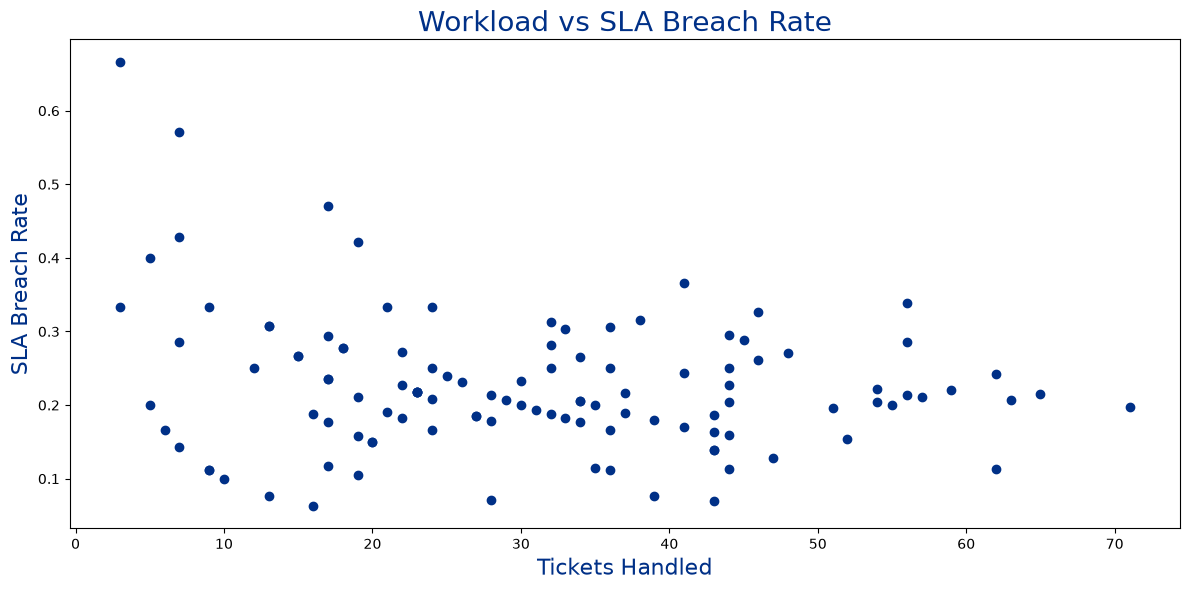

In [79]:
# Workload per agent
agent_workload = tickets.groupby("AssignedAgentID")["TicketID"].count()
agent_sla = tickets.groupby("AssignedAgentID")["SLABreached"].mean()

workload_df = pd.DataFrame({
    "Workload": agent_workload,
    "SLA_Breach_Rate": agent_sla
})

plt.figure(figsize=(12, 6))
plt.scatter(workload_df["Workload"], workload_df["SLA_Breach_Rate"],
            color=colors["nhs_dark_blue"])

plt.title("Workload vs SLA Breach Rate", fontsize=20, color=colors["nhs_dark_blue"])
plt.xlabel("Tickets Handled", fontsize=16, color=colors["nhs_dark_blue"])
plt.ylabel("SLA Breach Rate", fontsize=16, color=colors["nhs_dark_blue"])
plt.tight_layout()
plt.show()


In [87]:
import os

os.makedirs("data/processed", exist_ok=True)


In [88]:
tickets.to_csv(
    r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\NorthBridge_Health\Data\processed\tickets_clean.csv",
    index=False
)

clients.to_csv(
    r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\NorthBridge_Health\Data\processed\clients_clean.csv",
    index=False
)

agents.to_csv(
    r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\NorthBridge_Health\Data\processed\agents_clean.csv",
    index=False
)

audit.to_csv(
    r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\NorthBridge_Health\Data\processed\audit_clean.csv",
    index=False
)

escalations.to_csv(
    r"C:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\NorthBridge_Health\Data\processed\escalations_clean.csv",
    index=False
)


In [89]:
import os
print(os.getcwd())


c:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\NorthBridge_Health\Notebook
